=== Installing Required Libraries (Kaggle-safe) ===
✓ GPU: Tesla T4
✓ CUDA: 12.4 | PyTorch: 2.6.0+cu124
✓ VRAM: 14.6 GB

=== Dataset Discovery (Robust) ===
✓ Using dataset root: /kaggle/input/sleep-edf-dataset-expanded/sleep-edf-database-expanded-1.0.0
✓ Found 394 EDF files (recursive)
  PSG files: 197
  Hypnogram files: 197
✓ Total PSG/Hypnogram pairs: 197

=== Data Preprocessing ===
Processing recordings...
Processing 20 recordings...
Processing: SC4312E0-PSG.edf
  Using channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal']
  ✓ 2700 epochs | distribution {0: 1832, 1: 152, 2: 334, 3: 191, 4: 191}
Processing: SC4012E0-PSG.edf
  Using channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal']
  ✓ 2848 epochs | distribution {0: 1824, 1: 92, 2: 660, 3: 96, 4: 176}
Processing: SC4412E0-PSG.edf
  Using channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal']
  ✓ 2765 epochs | distribution {0: 2019, 1: 64, 2: 356, 3: 226, 4: 100}
Processing: SC4212E0-PSG.edf
  Using channels: ['EEG Fpz-Cz', 'E

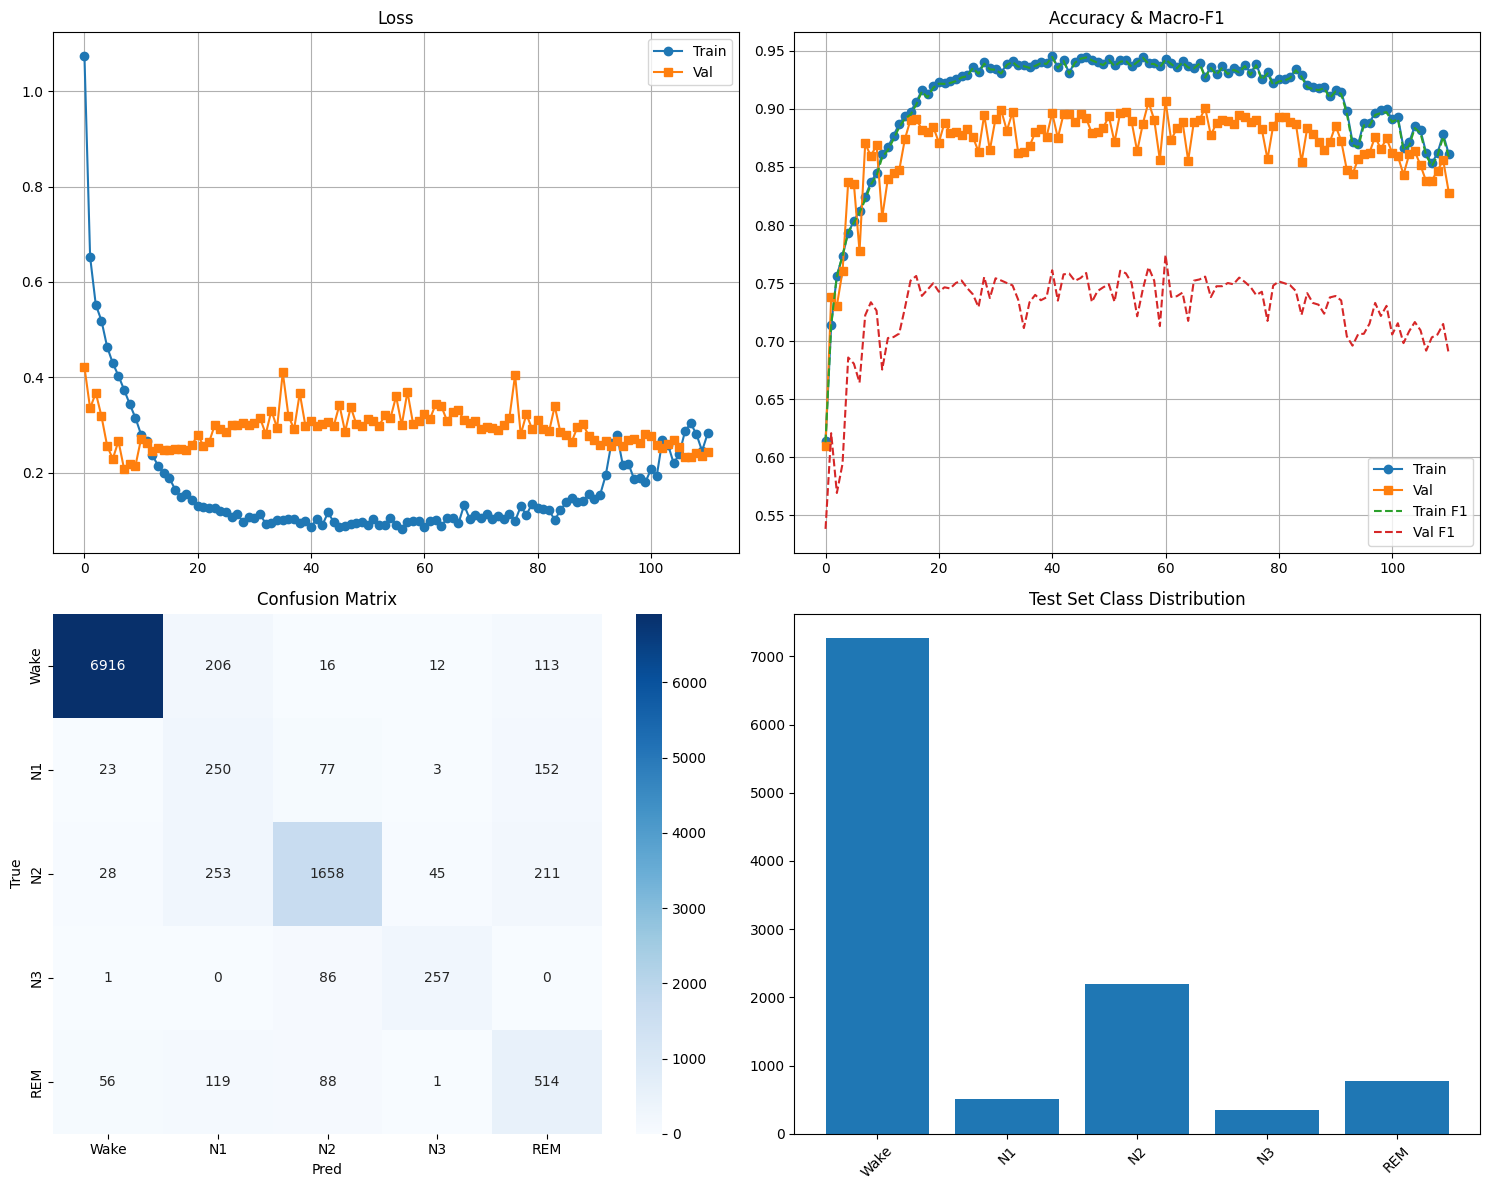


Detailed Classification Report:

              precision    recall  f1-score   support

        Wake     0.9846    0.9522    0.9682      7263
          N1     0.3019    0.4950    0.3751       505
          N2     0.8613    0.7554    0.8049      2195
          N3     0.8082    0.7471    0.7764       344
         REM     0.5192    0.6607    0.5814       778

    accuracy                         0.8656     11085
   macro avg     0.6950    0.7221    0.7012     11085
weighted avg     0.8910    0.8656    0.8757     11085


Prediction Pattern Analysis
Top 5 Misclassifications:
  1. N2 → N1: 253 (2.3%)
  2. N2 → REM: 211 (1.9%)
  3. Wake → N1: 206 (1.9%)
  4. N1 → REM: 152 (1.4%)
  5. REM → N1: 119 (1.1%)

Per-Class Accuracy:
  Wake: 0.9522
  N1: 0.4950
  N2: 0.7554
  N3: 0.7471
  REM: 0.6607

=== Resource Usage Summary ===
Peak GPU Memory Used: 0.52 GB
Current GPU Memory:   0.02 GB

✓ Saved /kaggle/working/sleep_tiny_mixer_final.pt and plots.

🎉 Pipeline Completed (Kaggle-safe).


In [ ]:
# ================================================================
# Sleep Stage Classification on Sleep-EDF Expanded (Kaggle-safe)
# - Robust pairing for PSG/Hypnogram (EC/E0, JA/J0 variants)
# - Conv1d + Gated Residual + BiGRU (compact, <1M params)
# - Class-weighted Focal Loss + WeightedRandomSampler (imbalance)
# - Early Stopping on validation macro-F1 (patience configurable)
# - Multi-GPU via nn.DataParallel + AMP for speed
# ================================================================

import os, gc, warnings, re
warnings.filterwarnings('ignore')

print("=== Installing Required Libraries (Kaggle-safe) ===")
!pip install mne scikit-learn matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, cohen_kappa_score, classification_report)
from sklearn.utils.class_weight import compute_class_weight

# -------------------------------
# Reproducibility
# -------------------------------
torch.manual_seed(42)
np.random.seed(42)

# -------------------------------
# GPU setup
# -------------------------------
def verify_gpu():
    if not torch.cuda.is_available():
        print("❌ This notebook requires a GPU (enable in Kaggle settings).")
        raise RuntimeError("GPU not available")
    dev = torch.device("cuda")
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ CUDA: {torch.version.cuda} | PyTorch: {torch.__version__}")
    print(f"✓ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    torch.cuda.empty_cache()
    return dev

device = verify_gpu()

# ================================================================
# Robust Dataset Discovery & Pairing (Sleep-EDF Expanded)
# ================================================================
print("\n=== Dataset Discovery (Robust) ===")

CANDIDATE_ROOTS = [
    "/kaggle/input/sleep-edf-dataset-expanded/sleep-edf-database-expanded-1.0.0",
    "/kaggle/input/sleep-edf-database-expanded-1-0-0/sleep-edf-database-expanded-1.0.0",
    "/kaggle/input/sleep-edf-expanded/sleep-edf-database-expanded-1.0.0",
]

def find_dataset_root():
    for p in CANDIDATE_ROOTS:
        if Path(p).exists():
            return Path(p)
    base = Path("/kaggle/input")
    candidates = [d for d in base.glob("**/sleep-edf-database-expanded-1.0.0") if d.is_dir()]
    if candidates:
        return candidates[0]
    raise RuntimeError("Sleep-EDF Expanded dataset root not found. Add it to the notebook.")

dataset_root = find_dataset_root()
print(f"✓ Using dataset root: {dataset_root}")

all_edf = list(dataset_root.rglob("*.edf"))
print(f"✓ Found {len(all_edf)} EDF files (recursive)")

psg_files = [f for f in all_edf if re.search(r'psg', f.name, re.IGNORECASE)]
hyp_files = [f for f in all_edf if re.search(r'hypnogram', f.name, re.IGNORECASE)]

print(f"  PSG files: {len(psg_files)}")
print(f"  Hypnogram files: {len(hyp_files)}")

def subject_key(path: Path) -> str:
    stem = path.stem
    tok = stem.split('-')[0]
    m = re.match(r'^(SC|ST)\d{4}[A-Z]\w?', tok, re.IGNORECASE)
    if m:
        return tok[:7].upper()
    return tok[:7].upper()

from collections import defaultdict
hyp_by_key = defaultdict(list)
for hf in hyp_files:
    hyp_by_key[subject_key(hf)].append(hf)

pairs = []
unpaired = []
for pf in psg_files:
    key = subject_key(pf)
    cands = hyp_by_key.get(key, [])
    if cands:
        tok = pf.stem.split('-')[0]
        best = max(
            cands,
            key=lambda h: len(os.path.commonprefix([tok.upper(), h.stem.split('-')[0].upper()]))
        )
        pairs.append((pf, best))
    else:
        unpaired.append(pf)

print(f"✓ Total PSG/Hypnogram pairs: {len(pairs)}")
if len(pairs) == 0:
    print("⚠️ Sample filenames:")
    for s in [p.name for p in all_edf[:10]]:
        print("   ", s)
    raise RuntimeError("No PSG/Hypnogram pairs found with robust matching.")

file_pairs = pairs

# ================================================================
# Preprocessing
# ================================================================
print("\n=== Data Preprocessing ===")

SLEEP_STAGE_MAPPING = {
    "Sleep stage W": 0, "W": 0, "Wake": 0,
    "Sleep stage 1": 1, "N1": 1, "Stage 1": 1,
    "Sleep stage 2": 2, "N2": 2, "Stage 2": 2,
    "Sleep stage 3": 3, "N3": 3, "Stage 3": 3,
    "Sleep stage 4": 3,
    "Sleep stage R": 4, "R": 4, "REM": 4
}
STAGE_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']

def process_single_recording(psg_file, hyp_file, target_channels=None, epoch_length=30.0):
    if target_channels is None:
        target_channels = ["EEG Fpz-Cz", "EEG Pz-Oz", "EOG horizontal"]
    try:
        print(f"Processing: {psg_file.name}")
        raw_psg = mne.io.read_raw_edf(str(psg_file), preload=True)
        annotations = mne.read_annotations(str(hyp_file))
        raw_psg.set_annotations(annotations)

        # channel selection (fuzzy matching)
        avail = []
        for t in target_channels:
            if t in raw_psg.ch_names:
                avail.append(t)
            else:
                t_clean = re.sub(r"[ \-]", "", t).lower()
                for ch in raw_psg.ch_names:
                    ch_clean = re.sub(r"[ \-]", "", ch).lower()
                    if t_clean in ch_clean or ch_clean in t_clean:
                        avail.append(ch); break
        if not avail:
            raise ValueError("No target channels found.")

        raw_psg.pick_channels(avail)
        print(f"  Using channels: {avail}")

        raw_psg.filter(l_freq=0.5, h_freq=35.0, fir_design='firwin')
        if raw_psg.info['sfreq'] > 100:
            raw_psg.resample(100)
            print("  Resampled to 100 Hz")

        unique_desc = set(a['description'] for a in annotations)
        event_id = {desc: SLEEP_STAGE_MAPPING[desc] for desc in unique_desc if desc in SLEEP_STAGE_MAPPING}

        events, _ = mne.events_from_annotations(
            raw_psg, event_id=event_id, chunk_duration=30.0
        )
        if len(events) == 0:
            raise ValueError("No sleep stage annotations found.")

        epochs = mne.Epochs(
            raw_psg, events, tmin=0.0,
            tmax=30.0 - 1/raw_psg.info['sfreq'],
            baseline=None, preload=True
        )
        X = epochs.get_data()               # (n_epochs, n_channels, n_samples)
        y_codes = events[:, -1]             # 0..4 per event_id

        mask = (y_codes >= 0) & (y_codes <= 4)
        X = X[mask]
        y = y_codes[mask]

        subj = psg_file.name.split('-')[0]
        print(f"  ✓ {len(X)} epochs | distribution {dict(Counter(y))}")

        del raw_psg, epochs, annotations
        gc.collect()
        return X, y, subj

    except Exception as e:
        print(f"  ❌ Error processing {psg_file.name}: {e}")
        return None, None, None

print("Processing recordings...")
all_X, all_y, all_subjects = [], [], []
# Keep modest for fast training; increase if you have time
pairs_to_process = file_pairs[:20]
print(f"Processing {len(pairs_to_process)} recordings...")

for psg_file, hyp_file in pairs_to_process:
    X, y, sid = process_single_recording(psg_file, hyp_file)
    if X is not None:
        all_X.append(X)
        all_y.append(y)
        all_subjects.append([sid] * len(y))

if not all_X:
    raise RuntimeError("No data processed successfully!")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
subjects_all = np.concatenate(all_subjects, axis=0)

print(f"\n✓ Total processed data: {X_all.shape}")
print(f"  Subjects: {len(np.unique(subjects_all))}")
print("  Global distribution:", dict(Counter(y_all)))

del all_X, all_y, all_subjects
gc.collect()

# ================================================================
# Normalization + Splits
# ================================================================
print("\n=== Data Normalization and Splitting ===")
n_epochs, n_channels, n_timepoints = X_all.shape
X_reshaped = X_all.reshape(n_epochs, n_channels * n_timepoints)

feat_scaler = StandardScaler()
X_normalized = feat_scaler.fit_transform(X_reshaped).reshape(n_epochs, n_channels, n_timepoints)
print("✓ Data normalized")

# Subject-wise split to prevent leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_normalized, y_all, subjects_all))
X_train, X_test = X_normalized[train_idx], X_normalized[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"  Train: {X_train.shape[0]}")
print(f"  Val  : {X_val.shape[0]}")
print(f"  Test : {X_test.shape[0]}")

# ================================================================
# Dataset & Sampler (imbalance-aware)
# ================================================================
class SleepDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_dataset = SleepDataset(X_train, y_train)
val_dataset   = SleepDataset(X_val, y_val)
test_dataset  = SleepDataset(X_test, y_test)

# Class weights (for loss) + sample weights (for sampler)
classes = np.unique(y_train)
cls_w = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(cls_w, dtype=torch.float32, device=device)
sample_weights = torch.tensor([cls_w[label] for label in y_train], dtype=torch.double)  # CPU
weighted_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

print(f"✓ Class weights (train): {cls_w}")

# ================================================================
# Model (Conv1d + gated residual + BiGRU)
# ================================================================
print("\n=== Model Definition (Tiny Mixer) ===")

class GatedConvBlock(nn.Module):
    def __init__(self, d_model, d_conv=5, dropout=0.1):
        super().__init__()
        self.dw = nn.Conv1d(d_model, d_model, kernel_size=d_conv, padding=d_conv//2, groups=d_model)
        self.pw = nn.Conv1d(d_model, d_model, kernel_size=1)
        self.gate = nn.Conv1d(d_model, d_model, kernel_size=1)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):           # x: (B, T, C)
        r = x
        x = x.transpose(1, 2)       # (B, C, T)
        x = self.dw(x)
        v = torch.tanh(self.pw(x))
        g = torch.sigmoid(self.gate(x))
        x = v * g
        x = x.transpose(1, 2)       # (B, T, C)
        x = self.drop(x)
        return self.norm(x + r)

class SleepTinyMixer(nn.Module):
    def __init__(self, n_channels, n_timepoints, d_model=64, n_classes=5, dropout=0.3, rnn_hidden=96):
        super().__init__()
        self.inp = nn.Conv1d(n_channels, d_model, kernel_size=3, padding=1)
        self.mix1 = GatedConvBlock(d_model, d_conv=9, dropout=dropout)
        self.mix2 = GatedConvBlock(d_model, d_conv=7, dropout=dropout)
        self.rnn  = nn.GRU(input_size=d_model, hidden_size=rnn_hidden, num_layers=1, batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(2*rnn_hidden)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(2*rnn_hidden, n_classes))
        self.apply(self._init)
    def _init(self, m):
        if isinstance(m, (nn.Linear, nn.Conv1d)):
            nn.init.xavier_uniform_(m.weight)
            if getattr(m, "bias", None) is not None: nn.init.zeros_(m.bias)
    def forward(self, x):                           # x: (B, C, T)
        x = self.inp(x).transpose(1, 2)            # (B, T, C=d_model)
        x = self.mix1(x)
        x = self.mix2(x)
        x, _ = self.rnn(x)                          # (B, T, 2*rnn_hidden)
        x = x.mean(dim=1)                           # global avg over time
        x = self.norm(x)
        return self.head(x)                         # (B, n_classes)

model = SleepTinyMixer(
    n_channels=X_train.shape[1],
    n_timepoints=X_train.shape[2],
    d_model=64, n_classes=5, dropout=0.3, rnn_hidden=96
)

# Multi-GPU
gpu_count = torch.cuda.device_count()
if gpu_count > 1:
    print(f"✓ Using DataParallel over {gpu_count} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Params: {total_params:,} (~{total_params*4/1024/1024:.2f} MB)")

# ================================================================
# Loss (class-weighted focal) + Optim + Sched + Early Stopping
# ================================================================
print("\n=== Training Setup ===")

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, logits, target):
        logp = torch.log_softmax(logits, dim=1)
        p = torch.exp(logp)
        logp_t = logp[torch.arange(logits.size(0), device=logits.device), target]
        p_t = p[torch.arange(logits.size(0), device=logits.device), target]
        loss = -(1 - p_t)**self.gamma * logp_t
        if self.weight is not None:
            w = self.weight[target]
            loss = loss * w
        return loss.mean() if self.reduction == 'mean' else loss.sum()

# Hyperparams tuned for speed & accuracy tradeoff
EPOCHS   = 500       # increase for higher accuracy if time allows
BATCH_SZ = 32
LR       = 1e-3
PATIENCE = 50        # early stopping patience on macro-F1
MIN_DELTA= 1e-4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SZ, sampler=weighted_sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SZ, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SZ, shuffle=False,
                          num_workers=2, pin_memory=True)

criterion = FocalLoss(weight=class_weights, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
amp_scaler = torch.cuda.amp.GradScaler()

print(f"✓ Epochs: {EPOCHS} | Batch: {BATCH_SZ} | LR: {LR} | Patience: {PATIENCE}")

def run_epoch(loader, train=True):
    if train: model.train()
    else:     model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_tgts = [], []
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train: optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                out = model(xb)
                loss = criterion(out, yb)
            if train:
                amp_scaler.scale(loss).backward()
                amp_scaler.step(optimizer)
                amp_scaler.update()
            total_loss += loss.item()
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
            all_preds.append(pred.detach().cpu().numpy())
            all_tgts.append(yb.detach().cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_tgts  = np.concatenate(all_tgts)
    acc = correct / max(1, total)
    # macro-F1 is the key metric on imbalance
    macro_f1 = precision_recall_fscore_support(all_tgts, all_preds, average='macro', zero_division=0)[2]
    return total_loss / max(1, len(loader)), acc, macro_f1

best_val_f1 = -1.0
best_val_acc = 0.0
wait = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

print("\n=== Training ===")
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_loader,   train=False)
    scheduler.step()

    train_losses.append(tr_loss);  val_losses.append(vl_loss)
    train_accs.append(tr_acc);     val_accs.append(vl_acc)
    train_f1s.append(tr_f1);       val_f1s.append(vl_f1)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train: loss {tr_loss:.4f} acc {tr_acc:.4f} f1 {tr_f1:.4f} | "
          f"Val:   loss {vl_loss:.4f} acc {vl_acc:.4f} f1 {vl_f1:.4f} | "
          f"LR {scheduler.get_last_lr()[0]:.6f}")

    improved = (vl_f1 > best_val_f1 + MIN_DELTA)
    if improved:
        best_val_f1 = vl_f1
        best_val_acc = max(best_val_acc, vl_acc)
        sd = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(sd, '/kaggle/working/best_model.pt')
        print("  ✓ Saved new best model (by macro-F1).")
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"  ⏹ Early stopping (patience={PATIENCE}).")
            break

print(f"\nBest val macro-F1: {best_val_f1:.4f} | Best val acc: {best_val_acc:.4f}")

# ================================================================
# Evaluation
# ================================================================
print("\n=== Evaluation ===")
if isinstance(model, nn.DataParallel):
    model.module.load_state_dict(torch.load('/kaggle/working/best_model.pt', map_location=device))
else:
    model.load_state_dict(torch.load('/kaggle/working/best_model.pt', map_location=device))

def collect_preds(loader):
    model.eval()
    P, T = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            pred = out.argmax(1).cpu().numpy()
            P.append(pred); T.append(yb.numpy())
    return np.concatenate(P), np.concatenate(T)

test_preds, test_targets = collect_preds(test_loader)

test_accuracy = accuracy_score(test_targets, test_preds)
precision, recall, f1, support = precision_recall_fscore_support(
    test_targets, test_preds, average=None, labels=[0,1,2,3,4], zero_division=0
)
macro_f1 = precision_recall_fscore_support(test_targets, test_preds, average='macro', zero_division=0)[2]
weighted_f1 = precision_recall_fscore_support(test_targets, test_preds, average='weighted', zero_division=0)[2]
kappa = cohen_kappa_score(test_targets, test_preds)
cm = confusion_matrix(test_targets, test_preds, labels=[0,1,2,3,4])

print(f"Overall Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1-Score:       {macro_f1:.4f}")
print(f"Weighted F1-Score:    {weighted_f1:.4f}")
print(f"Cohen's Kappa:        {kappa:.4f}")
print("\nPer-Class:")
for i, s in enumerate(STAGE_NAMES):
    print(f"{s:>4}: P={precision[i]:.3f} R={recall[i]:.3f} F1={f1[i]:.3f} N={support[i]}")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes[0,0].plot(train_losses, label='Train', marker='o')
axes[0,0].plot(val_losses, label='Val', marker='s')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(train_accs, label='Train', marker='o')
axes[0,1].plot(val_accs, label='Val', marker='s')
axes[0,1].plot(train_f1s, label='Train F1', linestyle='--')
axes[0,1].plot(val_f1s, label='Val F1', linestyle='--')
axes[0,1].set_title('Accuracy & Macro-F1'); axes[0,1].legend(); axes[0,1].grid(True)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=STAGE_NAMES, yticklabels=STAGE_NAMES, ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix'); axes[1,0].set_xlabel('Pred'); axes[1,0].set_ylabel('True')

class_dist = Counter(test_targets)
stages = [STAGE_NAMES[i] for i in sorted(class_dist.keys())]
counts = [class_dist[i] for i in sorted(class_dist.keys())]
axes[1,1].bar(stages, counts)
axes[1,1].set_title('Test Set Class Distribution'); axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/kaggle/working/sleep_classification_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDetailed Classification Report:\n")
print(classification_report(test_targets, test_preds, target_names=STAGE_NAMES, digits=4, zero_division=0))

# Insights
def analyze_predictions(targets, predictions):
    print("\nPrediction Pattern Analysis")
    cm = confusion_matrix(targets, predictions, labels=[0,1,2,3,4])
    mis = []
    for i in range(len(STAGE_NAMES)):
        for j in range(len(STAGE_NAMES)):
            if i != j and cm[i][j] > 0:
                mis.append((STAGE_NAMES[i], STAGE_NAMES[j], cm[i][j]))
    mis.sort(key=lambda x: x[2], reverse=True)
    print("Top 5 Misclassifications:")
    for i, (t, p, c) in enumerate(mis[:5]):
        pct = c / np.sum(cm) * 100
        print(f"  {i+1}. {t} → {p}: {c} ({pct:.1f}%)")
    accs = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-Class Accuracy:")
    for s, a in zip(STAGE_NAMES, accs):
        if not np.isnan(a):
            print(f"  {s}: {a:.4f}")

analyze_predictions(test_targets, test_preds)

if torch.cuda.is_available():
    print("\n=== Resource Usage Summary ===")
    print(f"Peak GPU Memory Used: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")
    print(f"Current GPU Memory:   {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Save bundle for inference
bundle = {
    'model_state_dict': (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()),
    'model_params': {
        'n_channels': X_train.shape[1],
        'n_timepoints': X_train.shape[2],
        'd_model': 64,
        'n_classes': 5,
        'dropout': 0.3,
        'rnn_hidden': 96
    },
    'scaler_mean': feat_scaler.mean_.astype(np.float32),
    'scaler_scale': feat_scaler.scale_.astype(np.float32),
    'class_names': STAGE_NAMES,
    'test_accuracy': float(test_accuracy),
    'test_f1_macro': float(macro_f1),
    'cohen_kappa': float(kappa)
}
torch.save(bundle, '/kaggle/working/sleep_tiny_mixer_final.pt')
print("\n✓ Saved /kaggle/working/sleep_tiny_mixer_final.pt and plots.")

# Inference helper
def load_and_predict(model_path, new_data, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')):
    chk = torch.load(model_path, map_location=device)
    mdl = SleepTinyMixer(**chk['model_params']).to(device)
    mdl.load_state_dict(chk['model_state_dict'])
    mdl.eval()
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        x = torch.tensor(new_data, dtype=torch.float32, device=device)
        out = mdl(x)
        prob = torch.softmax(out, dim=1).cpu().numpy()
        pred = out.argmax(dim=1).cpu().numpy()
    return pred, prob

print("\n🎉 Pipeline Completed (Kaggle-safe).")


In [ ]:
# import os
# import json
# import numpy as np
# import mne
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from sklearn.model_selection import GroupShuffleSplit
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# from pathlib import Path
# import gc
# import re

# def subject_id(filename):
#     """Extract subject ID from filename"""
#     # For Sleep EDF, subject IDs are like SC4001E0, SC4002E0, etc.
#     return filename.split('-')[0]

# def find_pairs(root_path):
#     """Find PSG and Hypnogram file pairs using regex pattern matching"""
#     root = Path(root_path)
#     pairs = []

#     # Look for files in both sleep-cassette and sleep-telemetry folders
#     for subdir in ["sleep-cassette", "sleep-telemetry"]:
#         subdir_path = root / subdir
#         if not subdir_path.exists():
#             continue

#         # Get all EDF files
#         all_files = list(subdir_path.glob("*.edf"))

#         if len(all_files) == 0:
#             continue

#         print(f"\nProcessing {subdir} folder:")
#         print(f"Found {len(all_files)} EDF files")

#         # Get PSG files
#         psg_files = [f for f in all_files if 'PSG' in f.name.upper()]

#         for psg_file in psg_files:
#             psg_name = psg_file.name
#             print(f"\nProcessing PSG file: {psg_name}")

#             # Find index of first '-'
#             dash_idx = psg_name.find('-')

#             if dash_idx == -1 or dash_idx < 2:
#                 print(f"  ✗ Warning: Invalid filename format for {psg_name}")
#                 continue

#             # Get substring till index dash_idx - 2
#             base_part = psg_name[:dash_idx - 1]
#             print(f"  Base part: '{base_part}'")

#             # Create regex pattern: base_part + any_char + '-Hypnogram.edf'
#             pattern = re.escape(base_part) + r'.-Hypnogram\.edf$'
#             print(f"  Regex pattern: {pattern}")

#             # Find matching hypnogram file
#             matching_hyp = None
#             for file in all_files:
#                 if re.match(pattern, file.name, re.IGNORECASE):
#                     matching_hyp = file
#                     break

#             if matching_hyp:
#                 pairs.append((psg_file, matching_hyp))
#                 print(f"  ✓ Found pair: {psg_name} <-> {matching_hyp.name}")
#             else:
#                 print(f"  ✗ Warning: No hypnogram found for {psg_name}")
#                 # Debug: show all files that might be candidates
#                 candidates = [f.name for f in all_files if 'HYPNOGRAM' in f.name.upper()]
#                 print(f"    Available hypnogram files: {candidates}")

#     print(f"\nTotal pairs found: {len(pairs)}")
#     return pairs

# def process_pair(psg_file, hyp_file, channels, epoch_len=30.0):
#     """Process a PSG-Hypnogram pair"""
#     try:
#         # Read PSG data
#         raw = mne.io.read_raw_edf(str(psg_file), preload=True)

#         # Read hypnogram annotations
#         ann = mne.read_annotations(str(hyp_file))
#         raw.set_annotations(ann)

#         # Pick desired channels
#         available_channels = [ch for ch in channels if ch in raw.ch_names]
#         if not available_channels:
#             raise RuntimeError(f"None of the desired channels {channels} found in {psg_file.name}. Available: {raw.ch_names}")

#         raw.pick_channels(available_channels)
#         print(f"Using channels: {available_channels}")

#         # Sleep stage mapping
#         mapping = {
#             "Sleep stage W": 0,    # Wake
#             "Sleep stage 1": 1,    # N1
#             "Sleep stage 2": 2,    # N2
#             "Sleep stage 3": 3,    # N3
#             "Sleep stage 4": 3,    # N3 (combining N3 and N4)
#             "Sleep stage R": 4     # REM
#         }

#         # Extract events
#         events, event_id = mne.events_from_annotations(raw, event_id=mapping, chunk_duration=epoch_len)

#         if len(events) == 0:
#             raise RuntimeError(f"No valid sleep stage annotations found in {hyp_file.name}")

#         # Create epochs
#         epochs = mne.Epochs(raw, events, event_id=None, tmin=0.0, tmax=epoch_len-1/raw.info['sfreq'],
#                            baseline=None, preload=True, on_missing='ignore')

#         X = epochs.get_data()  # Shape: (n_epochs, n_channels, n_samples)
#         y = epochs.events[:, -1]

#         # Map event codes to sleep stages
#         inv_event_id = {v: k for k, v in event_id.items()}
#         y_mapped = np.array([mapping.get(inv_event_id.get(code), -1) for code in y])

#         # Filter out invalid labels
#         valid_mask = y_mapped != -1
#         X = X[valid_mask]
#         y_mapped = y_mapped[valid_mask]

#         print(f"Processed {len(X)} epochs from {psg_file.name}")
#         print(f"Sleep stage distribution: {np.bincount(y_mapped)}")

#         # Clean up memory
#         del raw, ann, epochs
#         gc.collect()

#         return X, y_mapped

#     except Exception as e:
#         print(f"Error processing {psg_file.name}: {str(e)}")
#         raise

# class ContextDataset(Dataset):
#     """Dataset class for sleep stage classification with context"""
#     def __init__(self, X, y, L=9):
#         self.X = X
#         self.y = y
#         self.L = L  # Context length

#     def __len__(self):
#         return len(self.X)

#     def __getitem__(self, idx):
#         # Get context window
#         start_idx = max(0, idx - self.L // 2)
#         end_idx = min(len(self.X), idx + self.L // 2 + 1)

#         # Pad if necessary
#         context_X = []
#         context_y = []

#         for i in range(start_idx, end_idx):
#             context_X.append(self.X[i])
#             context_y.append(self.y[i])

#         # Pad to L length if needed
#         while len(context_X) < self.L:
#             context_X.append(np.zeros_like(self.X[0]))
#             context_y.append(-1)  # Padding label

#         return torch.FloatTensor(np.array(context_X)), torch.LongTensor(np.array(context_y)), torch.LongTensor([self.y[idx]])

# class SleepMambaTiny(nn.Module):
#     """Simple sleep stage classification model"""
#     def __init__(self, in_ch, emb, n_classes):
#         super().__init__()
#         self.conv1 = nn.Conv1d(in_ch, emb, 7, padding=3)
#         self.conv2 = nn.Conv1d(emb, emb, 7, padding=3)
#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.classifier = nn.Linear(emb, n_classes)
#         self.dropout = nn.Dropout(0.5)

#     def forward(self, x):
#         # x shape: (batch, context_len, channels, samples)
#         batch_size, context_len, channels, samples = x.shape
#         x = x.view(batch_size * context_len, channels, samples)

#         x = F.relu(self.conv1(x))
#         x = F.relu(self.conv2(x))
#         x = self.pool(x).squeeze(-1)
#         x = self.dropout(x)
#         x = self.classifier(x)

#         # Reshape back to (batch, context_len, n_classes)
#         x = x.view(batch_size, context_len, -1)
#         return x

# def class_weights(y):
#     """Calculate class weights for imbalanced dataset"""
#     classes, counts = np.unique(y, return_counts=True)
#     weights = 1.0 / counts
#     weights = weights / weights.sum() * len(classes)
#     return torch.FloatTensor(weights)

# def verify_gpu_usage():
#     """Verify that GPU is being used properly"""
#     if torch.cuda.is_available():
#         print("=== GPU Verification ===")
#         print(f"CUDA available: {torch.cuda.is_available()}")
#         print(f"Device count: {torch.cuda.device_count()}")
#         print(f"Current device: {torch.cuda.current_device()}")
#         print(f"Device name: {torch.cuda.get_device_name()}")

#         # Create a small tensor to test GPU
#         test_tensor = torch.randn(10, 10).cuda()
#         print(f"Test tensor device: {test_tensor.device}")
#         print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.3f} GB")
#         print("========================")
#         return True
#     else:
#         print("GPU not available, using CPU")
#         return False

# def train_one_epoch(model, dataloader, device, criterion, optimizer, context_len):
#     """Train for one epoch"""
#     model.train()
#     total_loss = 0
#     correct = 0
#     total = 0

#     # Monitor GPU usage
#     if torch.cuda.is_available():
#         print(f"GPU memory before training: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

#     for batch_idx, (batch_x, batch_context_y, batch_y) in enumerate(dataloader):
#         # Explicitly move data to GPU
#         batch_x = batch_x.to(device, non_blocking=True)
#         batch_context_y = batch_context_y.to(device, non_blocking=True)
#         batch_y = batch_y.to(device, non_blocking=True).squeeze()

#         # Verify data is on GPU
#         if batch_idx == 0:
#             print(f"Batch data device: {batch_x.device}")
#             print(f"Model device: {next(model.parameters()).device}")

#         optimizer.zero_grad()

#         outputs = model(batch_x)  # (batch, context_len, n_classes)

#         # Use only the center prediction for training
#         center_idx = context_len // 2
#         center_outputs = outputs[:, center_idx, :]

#         loss = criterion(center_outputs, batch_y)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()
#         _, predicted = torch.max(center_outputs.data, 1)
#         total += batch_y.size(0)
#         correct += (predicted == batch_y).sum().item()

#         # Print GPU usage every 50 batches
#         if batch_idx % 50 == 0 and torch.cuda.is_available():
#             print(f"Batch {batch_idx}: GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

#         # Clear cache periodically to prevent OOM
#         if batch_idx % 10 == 0:
#             torch.cuda.empty_cache()

#     return total_loss / len(dataloader), correct / total

# def eval_model(model, dataloader, device, context_len):
#     """Evaluate the model"""
#     model.eval()
#     correct = 0
#     total = 0
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for batch_idx, (batch_x, batch_context_y, batch_y) in enumerate(dataloader):
#             # Explicitly move data to GPU
#             batch_x = batch_x.to(device, non_blocking=True)
#             batch_y = batch_y.to(device, non_blocking=True).squeeze()

#             outputs = model(batch_x)
#             center_idx = context_len // 2
#             center_outputs = outputs[:, center_idx, :]

#             _, predicted = torch.max(center_outputs.data, 1)
#             total += batch_y.size(0)
#             correct += (predicted == batch_y).sum().item()

#             all_preds.extend(predicted.cpu().numpy())
#             all_labels.extend(batch_y.cpu().numpy())

#             # Clear cache periodically
#             if batch_idx % 10 == 0:
#                 torch.cuda.empty_cache()

#     return correct / total, all_preds, all_labels

# def get_optimal_batch_size():
#     """Determine optimal batch size based on available GPU memory"""
#     if torch.cuda.is_available():
#         gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
#         print(f"GPU Memory: {gpu_memory_gb:.1f} GB")

#         # Adjust batch size based on GPU memory
#         if gpu_memory_gb >= 16:
#             return 16
#         elif gpu_memory_gb >= 8:
#             return 8
#         else:
#             return 4
#     return 4

# def print_detailed_metrics(y_true, y_pred, phase=""):
#     """Print detailed classification metrics"""
#     class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

#     print(f"\n=== {phase} Metrics ===")
#     print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}")
#     print(f"Macro F1-Score: {f1_score(y_true, y_pred, average='macro'):.4f}")
#     print(f"Weighted F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")

#     print("\nPer-class Performance:")
#     report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
#     for i, class_name in enumerate(class_names):
#         if str(i) in report:
#             precision = report[str(i)]['precision']
#             recall = report[str(i)]['recall']
#             f1 = report[str(i)]['f1-score']
#             support = report[str(i)]['support']
#             print(f"  {class_name}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, Support={support}")

#     print("\nConfusion Matrix:")
#     cm = confusion_matrix(y_true, y_pred)
#     print(cm)

#     # Class distribution
#     unique, counts = np.unique(y_true, return_counts=True)
#     print(f"\nTrue class distribution: {dict(zip(unique, counts))}")
#     unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
#     print(f"Predicted class distribution: {dict(zip(unique_pred, counts_pred))}")
#     print("=" * 50)

# def main():
#     # Set memory optimization flags
#     torch.backends.cudnn.benchmark = True
#     torch.backends.cudnn.deterministic = False

#     # Correct path to the Sleep EDF dataset in Kaggle
#     dataset_path = "/kaggle/input/sleep-edf-dataset-expanded/sleep-edf-database-expanded-1.0.0"
#     outdir = Path("/kaggle/working/")
#     outdir.mkdir(parents=True, exist_ok=True)

#     print(f"Looking for dataset at: {dataset_path}")

#     # Verify GPU usage
#     gpu_available = verify_gpu_usage()

#     # Check GPU availability
#     if torch.cuda.is_available():
#         num_gpus = torch.cuda.device_count()
#         print(f"Found {num_gpus} GPU(s)")
#         for i in range(num_gpus):
#             print(f"  GPU {i}: {torch.cuda.get_device_properties(i).name}")
#     else:
#         print("No GPU available, using CPU")

#     # Debug: List what's actually available
#     root = Path(dataset_path)
#     if root.exists():
#         print("Dataset root contents:")
#         for item in root.iterdir():
#             print(f"  {item.name} ({'dir' if item.is_dir() else 'file'})")
#             if item.is_dir():
#                 print(f"    Contents of {item.name}:")
#                 for subitem in item.iterdir():
#                     print(f"      {subitem.name}")
#     else:
#         print(f"Dataset path {dataset_path} does not exist!")
#         return

#     # Find PSG-Hypnogram pairs
#     pairs = find_pairs(dataset_path)
#     if not pairs:
#         print(f"No PSG/Hypnogram pairs found under {dataset_path}")
#         return

#     print(f"Found {len(pairs)} PSG-Hypnogram pairs")

#     # Process all pairs
#     all_X, all_y, all_groups = [], [], []

#     # Try multiple channel combinations
#     channel_options = [
#         ["EEG Fpz-Cz"],
#         ["EEG Pz-Oz"],
#         ["Fpz-Cz"],
#         ["Pz-Oz"]
#     ]

#     for psg_file, hyp_file in pairs:
#         subject = subject_id(psg_file.name)

#         processed = False
#         for channels in channel_options:
#             try:
#                 X, y = process_pair(psg_file, hyp_file, channels=channels, epoch_len=30.0)
#                 all_X.append(X)
#                 all_y.append(y)
#                 all_groups.append(np.full(len(y), subject))
#                 processed = True
#                 break
#             except Exception as e:
#                 continue

#         if not processed:
#             print(f"Failed to process {psg_file.name} with any channel configuration")

#         # Clear memory after each file
#         gc.collect()

#     if not all_X:
#         print("No data could be processed!")
#         return

#     # Concatenate all data
#     X_all = np.concatenate(all_X, axis=0)
#     y_all = np.concatenate(all_y, axis=0)
#     g_all = np.concatenate(all_groups, axis=0)

#     print(f"Total processed data: {X_all.shape}")
#     print(f"Sleep stage distribution: {np.bincount(y_all)}")

#     # Clear intermediate variables to save memory
#     del all_X, all_y, all_groups
#     gc.collect()

#     # Train/validation split by subjects
#     gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
#     train_idx, val_idx = next(gss.split(X_all, y_all, g_all))

#     X_train, y_train = X_all[train_idx], y_all[train_idx]
#     X_val, y_val = X_all[val_idx], y_all[val_idx]

#     print(f"Training data: {X_train.shape}")
#     print(f"Validation data: {X_val.shape}")

#     # Get optimal batch size
#     batch_size = get_optimal_batch_size()
#     print(f"Using batch size: {batch_size}")

#     # Create datasets and dataloaders
#     train_dataset = ContextDataset(X_train, y_train, L=9)
#     val_dataset = ContextDataset(X_val, y_val, L=9)

#     # Use smaller batch size and more workers
#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
#                             num_workers=2, pin_memory=True, drop_last=True)
#     val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
#                           num_workers=2, pin_memory=True)

#     # Initialize model and ensure GPU usage
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     print(f"Using device: {device}")

#     if torch.cuda.is_available():
#         print(f"CUDA device: {torch.cuda.get_device_name()}")
#         print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
#         torch.cuda.empty_cache()  # Clear any existing cache

#     model = SleepMambaTiny(in_ch=X_train.shape[1], emb=128, n_classes=5)

#     # Move model to GPU first
#     model = model.to(device)

#     # Use DataParallel for multi-GPU training (only if more than 1 GPU)
#     if torch.cuda.device_count() > 1:
#         print(f"Using DataParallel with {torch.cuda.device_count()} GPUs")
#         model = nn.DataParallel(model)
#     elif torch.cuda.is_available():
#         print(f"Using single GPU: {torch.cuda.get_device_name()}")
#     else:
#         print("Using CPU")

#     # Print model parameters
#     total_params = sum(p.numel() for p in model.parameters())
#     print(f"Model parameters: {total_params:,}")

#     # Loss function with class weights
#     weights = class_weights(y_train).to(device)
#     criterion = nn.CrossEntropyLoss(weight=weights)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)  # Reduced learning rate
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

#     # Training loop with detailed metrics
#     best_val_acc = 0.0
#     train_accuracies = []
#     val_accuracies = []

#     for epoch in range(20):
#         print(f"\nEpoch {epoch+1}/20")
#         train_loss, train_acc = train_one_epoch(model, train_loader, device, criterion, optimizer, 9)
#         val_acc, val_preds, val_labels = eval_model(model, val_loader, device, 9)

#         # Get training predictions for detailed metrics
#         _, train_preds, train_labels = eval_model(model, train_loader, device, 9)

#         train_accuracies.append(train_acc)
#         val_accuracies.append(val_acc)

#         # Update learning rate
#         scheduler.step(val_acc)
#         current_lr = optimizer.param_groups[0]['lr']

#         print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}")

#         # Print detailed metrics every 5 epochs
#         if epoch % 5 == 0 or epoch == 19:
#             print_detailed_metrics(train_labels, train_preds, f"Training (Epoch {epoch+1})")
#             print_detailed_metrics(val_labels, val_preds, f"Validation (Epoch {epoch+1})")

#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             # Save the model (handle DataParallel)
#             model_to_save = model.module if isinstance(model, nn.DataParallel) else model
#             torch.save(model_to_save.state_dict(), outdir / "best_model.pt")
#             print(f"New best model saved! Val Acc: {val_acc:.4f}")

#         # Clear cache after each epoch
#         torch.cuda.empty_cache()

#     print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.4f}")

#     # Final comprehensive evaluation
#     print("\n" + "="*70)
#     print("FINAL MODEL EVALUATION")
#     print("="*70)

#     # Load best model for final evaluation
#     model_to_load = model.module if isinstance(model, nn.DataParallel) else model
#     model_to_load.load_state_dict(torch.load(outdir / "best_model.pt"))

#     # Final metrics
#     final_train_acc, final_train_preds, final_train_labels = eval_model(model, train_loader, device, 9)
#     final_val_acc, final_val_preds, final_val_labels = eval_model(model, val_loader, device, 9)

#     print_detailed_metrics(final_train_labels, final_train_preds, "FINAL TRAINING")
#     print_detailed_metrics(final_val_labels, final_val_preds, "FINAL VALIDATION")

#     # Training history summary
#     print(f"\nTraining History Summary:")
#     print(f"Best Training Accuracy: {max(train_accuracies):.4f}")
#     print(f"Best Validation Accuracy: {max(val_accuracies):.4f}")
#     print(f"Final Training Accuracy: {final_train_acc:.4f}")
#     print(f"Final Validation Accuracy: {final_val_acc:.4f}")

# if __name__ == "__main__":
#     main()